# Movie Recommender System

In [1]:
# Uninstall current numpy
!pip uninstall -y numpy

Found existing installation: numpy 2.0.2
Uninstalling numpy-2.0.2:
  Successfully uninstalled numpy-2.0.2


In [2]:
# Install compatible numpy version (for task 3)
!pip install numpy==1.26.4

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 20.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
rasterio 1.5.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
opencv-python-headless 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
tobler 0.14.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
xarray-einstats 0.10.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
jax 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
pytensor 2.38.3 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatibl

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations
# load datasets
movies  = pd.read_csv('/content/drive/MyDrive/movie_lens/movies.csv')
ratings = pd.read_csv('/content/drive/MyDrive/movie_lens/ratings.csv')
tags    = pd.read_csv('/content/drive/MyDrive/movie_lens/tags.csv')
links   = pd.read_csv('/content/drive/MyDrive/movie_lens/links.csv')

#Task 1

### Data Exploration

In [3]:
# explore the movies data
print("Movies")
print(movies.shape)
print(movies.head(10))
print("\nGenres sample:")
print(movies["genres"].unique()[:10])

Movies
(9742, 3)
   movieId                               title  \
0        1                    Toy Story (1995)   
1        2                      Jumanji (1995)   
2        3             Grumpier Old Men (1995)   
3        4            Waiting to Exhale (1995)   
4        5  Father of the Bride Part II (1995)   
5        6                         Heat (1995)   
6        7                      Sabrina (1995)   
7        8                 Tom and Huck (1995)   
8        9                 Sudden Death (1995)   
9       10                    GoldenEye (1995)   

                                        genres  
0  Adventure|Animation|Children|Comedy|Fantasy  
1                   Adventure|Children|Fantasy  
2                               Comedy|Romance  
3                         Comedy|Drama|Romance  
4                                       Comedy  
5                        Action|Crime|Thriller  
6                               Comedy|Romance  
7                           Adventure|Ch

In [4]:
# explore the ratings data
print("Ratings")
print(ratings.shape)
print(ratings.head(5))

Ratings
(100836, 4)
   userId  movieId  rating  timestamp
0       1        1     4.0  964982703
1       1        3     4.0  964981247
2       1        6     4.0  964982224
3       1       47     5.0  964983815
4       1       50     5.0  964982931


In [5]:
# explore tags
tags.info()
print(f"\nunique users who tagged: {tags['userId'].nunique()}")
print(f"unique movies tagged: {tags['movieId'].nunique()}")
print(f"unique tags: {tags['tag'].nunique()}")
print(tags.head(10))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3683 entries, 0 to 3682
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   userId     3683 non-null   int64 
 1   movieId    3683 non-null   int64 
 2   tag        3683 non-null   object
 3   timestamp  3683 non-null   int64 
dtypes: int64(3), object(1)
memory usage: 115.2+ KB

unique users who tagged: 58
unique movies tagged: 1572
unique tags: 1589
   userId  movieId                tag   timestamp
0       2    60756              funny  1445714994
1       2    60756    Highly quotable  1445714996
2       2    60756       will ferrell  1445714992
3       2    89774       Boxing story  1445715207
4       2    89774                MMA  1445715200
5       2    89774          Tom Hardy  1445715205
6       2   106782              drugs  1445715054
7       2   106782  Leonardo DiCaprio  1445715051
8       2   106782    Martin Scorsese  1445715056
9       7    48516       way too l

In [6]:
# explore links
print("links info")
links.info()
print(f"\nmissing imdb links: {links['imdbId'].isnull().sum()}")
print(f"missing tmdbId: {links['tmdbId'].isnull().sum()}")
print(links.head(5))

links info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9742 entries, 0 to 9741
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   movieId  9742 non-null   int64  
 1   imdbId   9742 non-null   int64  
 2   tmdbId   9734 non-null   float64
dtypes: float64(1), int64(2)
memory usage: 228.5 KB

missing imdb links: 0
missing tmdbId: 8
   movieId  imdbId   tmdbId
0        1  114709    862.0
1        2  113497   8844.0
2        3  113228  15602.0
3        4  114885  31357.0
4        5  113041  11862.0


In [7]:
# 18 unique genres after excluding imax and no genres listed
all_genres = (
    movies["genres"].str.split("|").explode()
    .loc[lambda x: ~x.isin(['(no genres listed)', 'IMAX'])]
    .unique()
)
print(sorted(all_genres))
print(f"\nTotal unique individual genres: {len(all_genres)}")

['Action', 'Adventure', 'Animation', 'Children', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Fantasy', 'Film-Noir', 'Horror', 'Musical', 'Mystery', 'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western']

Total unique individual genres: 18


18 actually if we don't count no genres listed and imax

In [8]:
# check types and msising values for movies
print("movies data types")
print(movies.dtypes)
print("\nmissing values")
print(movies.isnull().sum())
print("\nduplicate movieIds")
print(f"Duplicate movieIds: {movies['movieId'].duplicated().sum()}")

movies data types
movieId     int64
title      object
genres     object
dtype: object

missing values
movieId    0
title      0
genres     0
dtype: int64

duplicate movieIds
Duplicate movieIds: 0


In [9]:
# see how many times each rating appears
print("rating value counts")
print(ratings['rating'].value_counts().sort_index())

rating value counts
rating
0.5     1370
1.0     2811
1.5     1791
2.0     7551
2.5     5550
3.0    20047
3.5    13136
4.0    26818
4.5     8551
5.0    13211
Name: count, dtype: int64


This tells us users generally rate movies they chose to watch and liked, which makes sense, people tend to watch movies they expect to enjoy and rate them accordingly. This is known as selection bias in recommender systems.

In [10]:
# ratings per movie
ratings_per_movie = ratings.groupby('movieId')['rating'].count()
print("ratings per movie stats")
print(ratings_per_movie.describe())
print(f"\nmovies with only 1 rating: {(ratings_per_movie == 1).sum()}")
print(f"movies with more than 100 ratings: {(ratings_per_movie > 100).sum()}")

ratings per movie stats
count    9724.000000
mean       10.369807
std        22.401005
min         1.000000
25%         1.000000
50%         3.000000
75%         9.000000
max       329.000000
Name: rating, dtype: float64

movies with only 1 rating: 3446
movies with more than 100 ratings: 134


In [11]:
# ratings per user
ratings_per_user = ratings.groupby('userId')['rating'].count()
print("ratings per user stats")
print(ratings_per_user.describe())
print(f"\nusers with less than 50 ratings: {(ratings_per_user < 50).sum()}")
print(f"users with more than 100 ratings: {(ratings_per_user > 100).sum()}")

ratings per user stats
count     610.000000
mean      165.304918
std       269.480584
min        20.000000
25%        35.000000
50%        70.500000
75%       168.000000
max      2698.000000
Name: rating, dtype: float64

users with less than 50 ratings: 225
users with more than 100 ratings: 245


This is a classic long tail distribution, a small number of popular movies have hundreds of ratings while the vast majority have very few. We can see that clearly:

3,446 movies have only 1 rating, that's 35% of all rated movies
Only 134 movies have more than 100 ratings
Max is 329 ratings for one movie
75th percentile is just 9, meaning 75% of movies have 9 or fewer ratings

This is really important for our recommender system, for Task 3 personalized recommendations, movies with very few ratings will be hard to recommend confidently since we don't have enough signal about them. This is known as the cold start problem.

In [12]:
# convert timestamps to datetime
tags['timestamp'] = pd.to_datetime(tags['timestamp'], unit='s')
print(f"earliest tag: {tags['timestamp'].min()}")
print(f"latest tag: {tags['timestamp'].max()}")
print(f"\nduplicate tags: {tags.duplicated().sum()}")

earliest tag: 2006-01-13 19:09:12
latest tag: 2018-09-16 11:50:03

duplicate tags: 0


Tags span from 2006 to 2018 a narrower range than ratings which started in 1996, meaning tagging was a feature added later to MovieLens and there are no duplicate tags

In [13]:
# convert timestamp to datetime, timestamp is in seconds
ratings['timestamp'] = pd.to_datetime(ratings['timestamp'], unit='s')
print(f"earliest rating: {ratings['timestamp'].min()}")
print(f"latest rating: {ratings['timestamp'].max()}")

earliest rating: 1996-03-29 18:36:55
latest rating: 2018-09-24 14:27:30


In [14]:
# how many movies per genre
# count how many times each genre appeared across all movies
genre_counts = movies['genres'].str.split('|').explode()
genre_counts = genre_counts[genre_counts != '(no genres listed)']
genre_counts = genre_counts[genre_counts != 'IMAX']
genre_counts = genre_counts.value_counts()
print("genre distribution")
print(genre_counts)

genre distribution
genres
Drama          4361
Comedy         3756
Thriller       1894
Action         1828
Romance        1596
Adventure      1263
Crime          1199
Sci-Fi          980
Horror          978
Fantasy         779
Children        664
Animation       611
Mystery         573
Documentary     440
War             382
Musical         334
Western         167
Film-Noir        87
Name: count, dtype: int64


In [15]:
# average number of movies per genre
movies['genre_count'] = movies['genres'].apply(
    lambda x: 0 if x == '(no genres listed)' else len(x.split('|'))
)
print("genre count stats")
print(movies['genre_count'].describe())
print(f"\nNumber of movies with only 1 genre: {(movies['genre_count'] == 1).sum()}")
movies = movies.drop(columns='genre_count')

genre count stats
count    9742.000000
mean        2.263396
std         1.128720
min         0.000000
25%         1.000000
50%         2.000000
75%         3.000000
max        10.000000
Name: genre_count, dtype: float64

Number of movies with only 1 genre: 2817


### Visualizations

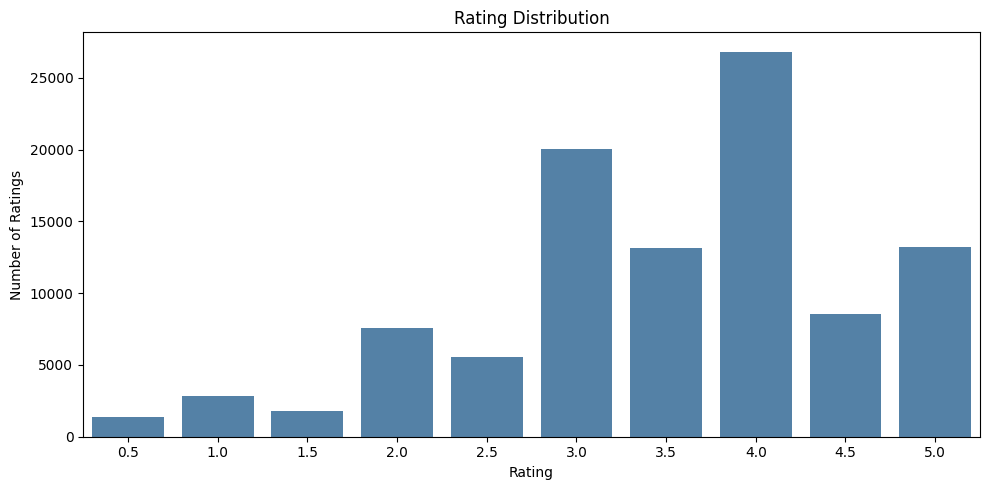

In [16]:
# rating distribution
ratings_counts = ratings['rating'].value_counts().sort_index()
plt.figure(figsize=(10, 5))
sns.barplot(x=ratings_counts.index, y=ratings_counts.values, color='steelblue')
plt.title('Rating Distribution')
plt.xlabel('Rating')
plt.ylabel('Number of Ratings')
plt.tight_layout()
plt.show()

ratings cluster heavily toward 3.0, 3.5, 4.0 and 5.0, with very few low ratings. The pattern of whole star ratings being taller than half star ratings is also immediately obvious in the chart

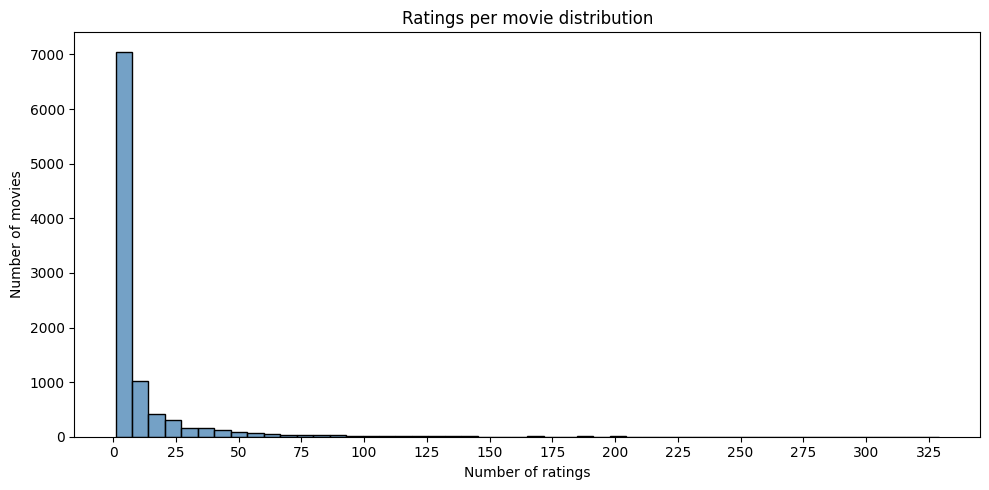

In [17]:
# ratings per movie distribution
plt.figure(figsize=(10, 5))
sns.histplot(ratings_per_movie, bins=50, color='steelblue')
plt.title("Ratings per movie distribution")
plt.xlabel("Number of ratings")
plt.ylabel("Number of movies")
plt.xticks(range(0, int(ratings_per_movie.max()) + 1, 25))
plt.tight_layout()
plt.show()

over 7000 movies have very few ratings (first bin), and it drops off dramatically after that. Almost no movies make it past 100 ratings.

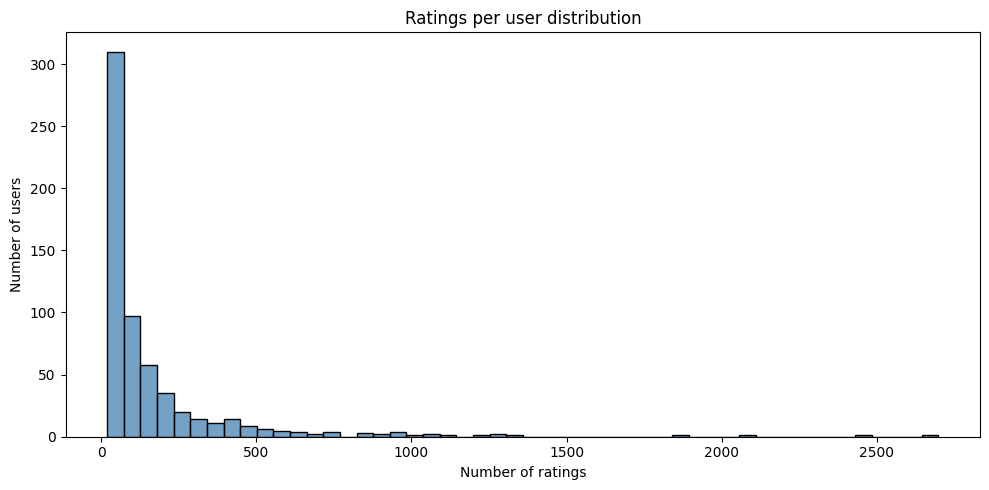

In [18]:
# ratings per user distribution
plt.figure(figsize=(10, 5))
sns.histplot(ratings_per_user, bins=50, color='steelblue')
plt.title("Ratings per user distribution")
plt.xlabel("Number of ratings")
plt.ylabel("Number of users")
plt.tight_layout()
plt.show()

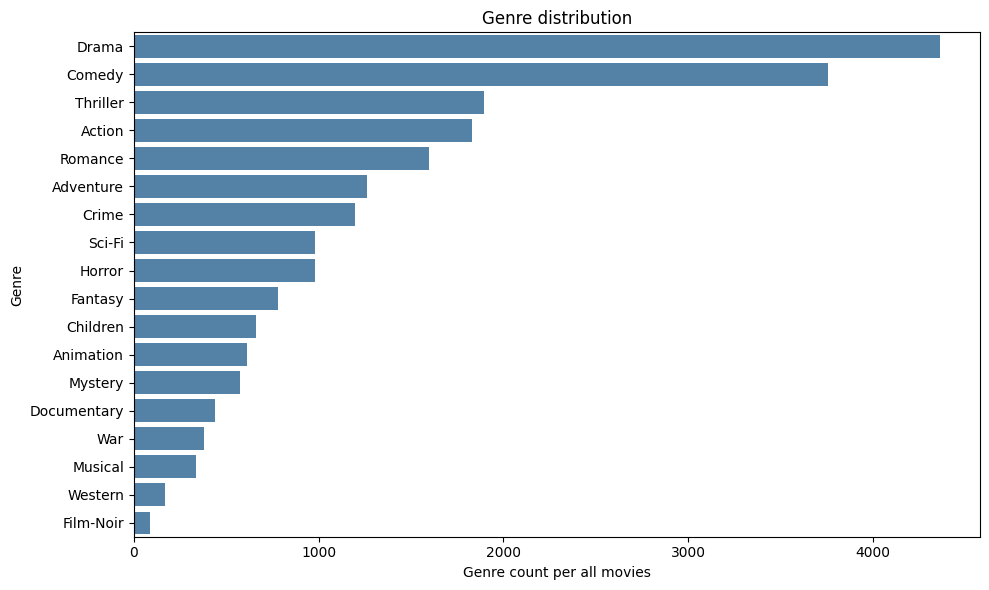

In [19]:
# genre distribution, we already created genre_counts earlier
plt.figure(figsize=(10, 6))
sns.barplot(x=genre_counts.values, y=genre_counts.index, color='steelblue')
plt.title("Genre distribution")
plt.xlabel("Genre count per all movies")
plt.ylabel("Genre")
plt.tight_layout()
plt.show()

Drama and comedy clearly dominate the dataset, appearing in far more movies than any other genre.
Thriller and action form a solid second tier, while Film-Noir and Western are the rarest by a
significant margin. This imbalance matters for our recommender: movies in rare genres have a
smaller pool of similar movies to choose from, which can lead to weaker recommendations for those genres.

In [20]:
# avg rating per genre, we already have avg_rating_per_genre
movies_ratings = ratings.merge(movies[['movieId', 'genres']], on='movieId')
movies_ratings['genres'] = movies_ratings['genres'].str.split('|')
movies_ratings = movies_ratings.explode('genres')
movies_ratings = movies_ratings[~movies_ratings['genres'].isin(['(no genres listed)', 'IMAX'])]
avg_rating_per_genre = (
    movies_ratings.groupby('genres')['rating']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'avg_rating', 'count': 'num_ratings'})
    .sort_values('avg_rating', ascending=False)
)
print("average rating per genre")
print(avg_rating_per_genre)

average rating per genre
             avg_rating  num_ratings
genres                              
Film-Noir      3.920115          870
War            3.808294         4859
Documentary    3.797785         1219
Crime          3.658294        16681
Drama          3.656184        41928
Mystery        3.632460         7674
Animation      3.629937         6988
Western        3.583938         1930
Musical        3.563678         4138
Adventure      3.508609        24161
Romance        3.506511        18124
Thriller       3.493706        26452
Fantasy        3.491001        11834
Sci-Fi         3.455721        17243
Action         3.447984        30635
Children       3.412956         9208
Comedy         3.384721        39053
Horror         3.258195         7291


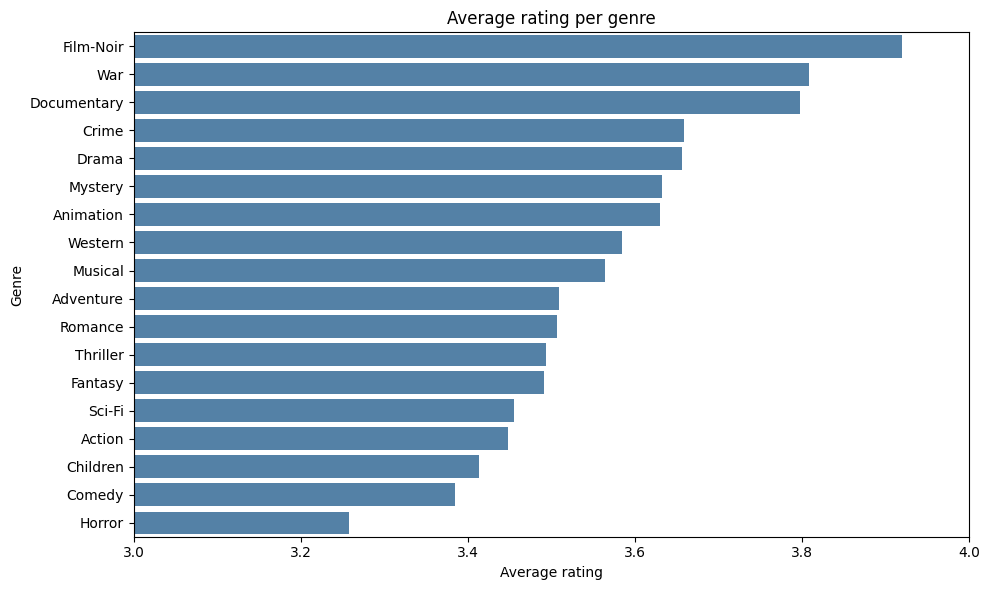

In [21]:
plt.figure(figsize=(10, 6))
sns.barplot(x='avg_rating', y=avg_rating_per_genre.index, data=avg_rating_per_genre, color='steelblue')
plt.title("Average rating per genre")
plt.xlabel('Average rating')
plt.ylabel('Genre')
plt.xlim(3.0, 4.0)
plt.tight_layout()
plt.show()

Film-Noir, War and Documentary consistently receive the highest average ratings despite being
among the rarest genres, likely because they attract more dedicated viewers.<br> Horror and Comedy
sit at the bottom, with Horror being the most polarizing genre in the dataset.<br> Interestingly,
Drama and Comedy are the most common genres but don't dominate in ratings, suggesting that
popularity and quality perception don't always go hand in hand.<br> The overall rating range across
genres is surprisingly narrow, only about 0.65 difference between the highest and lowest,
which is why the x-axis is zoomed in to make the differences visible.

In [22]:
# which genres appear together most often
genre_lists = movies['genres'].str.split('|').apply(
    lambda x: [g for g in x if g not in ['(no genres listed)', 'IMAX']]
)
# count co-occurences
# create a dataframe filled with zeros
# both the row index and column names are the 18 sorted genre names
# this allows us to cerate a matrix that shows co-occurences
cooccurrence = pd.DataFrame(0, index=sorted(all_genres), columns=sorted(all_genres))
for genres in genre_lists:
    for g1, g2 in combinations(genres, 2):
        cooccurrence.loc[g1, g2] += 1
        cooccurrence.loc[g2, g1] += 1
print(f"co-occurrence matrix shape: {cooccurrence.shape}")

co-occurrence matrix shape: (18, 18)


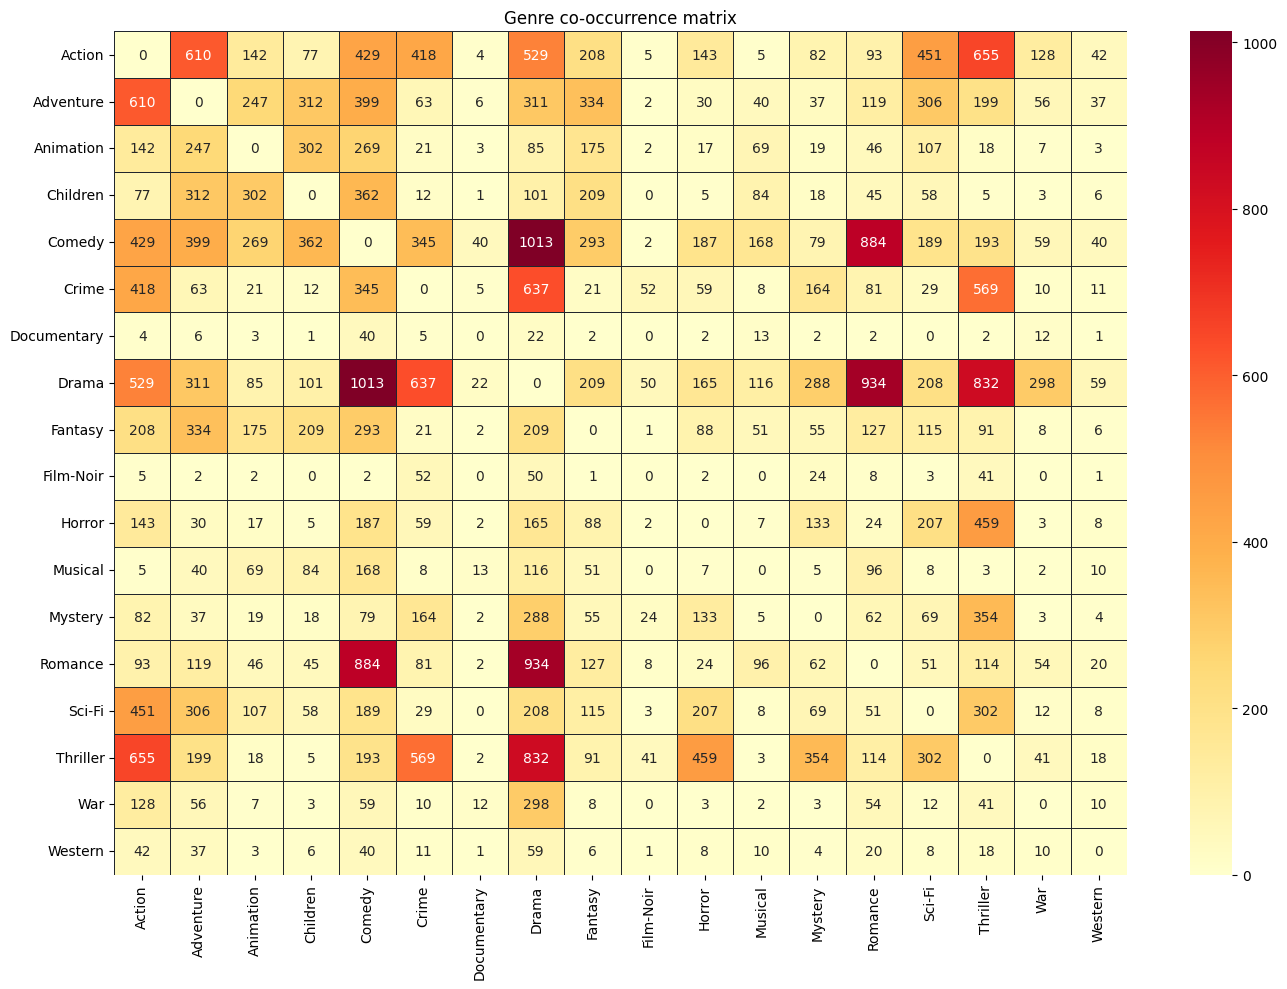

In [23]:
# visualising the matrix as a heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(
    cooccurrence,
    annot=True,
    fmt='d',         # format numbers as integers
    cmap='YlOrRd',   # yellow to red, darker means higher co-occurrence
    linewidths=0.5,
    linecolor='#21262d'
)
plt.title('Genre co-occurrence matrix')
plt.tight_layout()
plt.show()

Drama is the most connected genre, frequently pairing with Comedy, Romance, Thriller and Crime. Documentary, Film-Noir and Western are the most isolated genres with few strong pairings.

### Data Cleaning

In [24]:
# movies with no genres listed
no_genre = movies[movies['genres'] == '(no genres listed)']
print(f"movies with no genre: {len(no_genre)}")
print(no_genre)

movies with no genre: 34
      movieId                                              title  \
8517   114335                                  La cravate (1957)   
8684   122888                                     Ben-hur (2016)   
8687   122896  Pirates of the Caribbean: Dead Men Tell No Tal...   
8782   129250                                  Superfast! (2015)   
8836   132084                                Let It Be Me (1995)   
8902   134861               Trevor Noah: African American (2013)   
9033   141131                                   Guardians (2016)   
9053   141866                                  Green Room (2015)   
9070   142456                     The Brand New Testament (2015)   
9091   143410                                         Hyena Road   
9138   147250  The Adventures of Sherlock Holmes and Doctor W...   
9178   149330                          A Cosmic Christmas (1977)   
9217   152037                                 Grease Live (2016)   
9248   155589          

In [25]:
# find movies with duplicate titles
duplicate_titles = movies[movies.duplicated(subset='title', keep=False)]
print(duplicate_titles.sort_values('title'))

      movieId                                   title  \
4169     6003  Confessions of a Dangerous Mind (2002)   
9106   144606  Confessions of a Dangerous Mind (2002)   
650       838                             Emma (1996)   
5601    26958                             Emma (1996)   
5854    32600                             Eros (2004)   
9135   147002                             Eros (2004)   
2141     2851                         Saturn 3 (1980)   
9468   168358                         Saturn 3 (1980)   
5931    34048                War of the Worlds (2005)   
6932    64997                War of the Worlds (2005)   

                                   genres  
4169          Comedy|Crime|Drama|Thriller  
9106  Comedy|Crime|Drama|Romance|Thriller  
650                  Comedy|Drama|Romance  
5601                              Romance  
5854                                Drama  
9135                        Drama|Romance  
2141            Adventure|Sci-Fi|Thriller  
9468                

we will keep the duplicates that have the most genres listed that gives us more info about the movie and will help recommend similar ones

In [26]:
# extract the year from the each title and create a year column
movies['year'] = movies['title'].str.extract(r'\((\d{4})\)\s*\Z')
movies['title'] = movies['title'].str.replace(r'\s*\(\d{4}\)\s*\Z', '', regex=True).str.strip()
print("movies after year extraction")
print(movies.head(10))
print(f"\nmissing years: {movies['year'].isnull().sum()}")

movies after year extraction
   movieId                        title  \
0        1                    Toy Story   
1        2                      Jumanji   
2        3             Grumpier Old Men   
3        4            Waiting to Exhale   
4        5  Father of the Bride Part II   
5        6                         Heat   
6        7                      Sabrina   
7        8                 Tom and Huck   
8        9                 Sudden Death   
9       10                    GoldenEye   

                                        genres  year  
0  Adventure|Animation|Children|Comedy|Fantasy  1995  
1                   Adventure|Children|Fantasy  1995  
2                               Comedy|Romance  1995  
3                         Comedy|Drama|Romance  1995  
4                                       Comedy  1995  
5                        Action|Crime|Thriller  1995  
6                               Comedy|Romance  1995  
7                           Adventure|Children  1995  
8 

In [27]:
# movies with missing years
missing_years = movies[movies['year'].isnull()]
print("Movies with missing years")
print(missing_years[['movieId', 'title', 'genres']])

Movies with missing years
      movieId                                              title  \
6059    40697                                          Babylon 5   
9031   140956                                   Ready Player One   
9091   143410                                         Hyena Road   
9138   147250  The Adventures of Sherlock Holmes and Doctor W...   
9179   149334                                  Nocturnal Animals   
9259   156605                                           Paterson   
9367   162414                                          Moonlight   
9448   167570                                             The OA   
9514   171495                                             Cosmos   
9515   171631                            Maria Bamford: Old Baby   
9518   171749                  Death Note: Desu nôto (2006–2007)   
9525   171891                                  Generation Iron 2   
9611   176601                                       Black Mirror   

                     

In [28]:
# drop death note since it's a tv series with a range rather than a year of release
movies.drop(movies[movies['movieId'] == 171749].index, inplace=True)
print(f"movies after dropping Death Note: {len(movies)}")

movies after dropping Death Note: 9741


In [29]:
# convert the year column to numeric
# coerce tells to_numeric to convert a value it can't handle into NaN type
movies['year'] = pd.to_numeric(movies['year'], errors='coerce')
print(movies['year'].dtype)
print(movies['year'].agg(['min', 'max', 'median', 'count']))

float64
min       1902.0
max       2018.0
median    1999.0
count     9729.0
Name: year, dtype: float64


In [30]:
# sort so that movies with genre info come first
# count genres by list of genres split by |
# we sort the movies dataframe using this helper column we created, and we keep the first duplicate since it's the one with most genres
# drop the helper column
movies['genre_count'] = movies['genres'].apply(lambda x: len(x.split('|')))
movies = movies.sort_values('genre_count', ascending=False).drop_duplicates(
    subset=['title', 'year'], keep='first'
)
movies = movies.drop(columns='genre_count')
print(f"movies after removing duplicates: {len(movies)}")

movies after removing duplicates: 9736


In [31]:
# drop babylon 5 since it's a franchise with many movies and we don't know exactly which one this is
movies.drop(movies[movies['movieId'] == 40697].index, inplace=True)
print(f"movies shape: {movies.shape}")

movies shape: (9735, 4)


In [32]:
# checking the movies with missing tmdbids and filling them manually
print(links[links['tmdbId'].isnull()][['movieId', 'imdbId']])

      movieId  imdbId
624       791  113610
843      1107  102336
2141     2851   81454
3027     4051   56600
5532    26587   92337
5854    32600  377059
6059    40697  105946
7382    79299  874957


why looking for the missing tmdbids using the imdbids in links.csv, i noticed that the imdbid column stores the IDs as plain integers so leading 0s are removed.
<br>
so for the first movie, when i visited https://www.imdb.com/title/tt113610/ it gave me an error that the page doesn't exist but https://www.imdb.com/title/tt0113610/ worked normally. So i also tested with a movie that has a 5-digit imdbid which is 70820 and it turns out it needed to be padded with two 0s at the beginning so every imdb id (after the tt) is actually composed of at least 7 digits

In [33]:
# fill in missing tmdb ids for valid movies
links.loc[links['movieId'] == 791,  'tmdbId'] = 706007
links.loc[links['movieId'] == 2851, 'tmdbId'] = 19761
links.loc[links['movieId'] == 4051, 'tmdbId'] = 31392

In [34]:
# drop movieId 1107, not found on the tmdb website
# drop movieId 26587, it's a tv series, not a movie
# drop movieId 79299, it's an episode of a series, not a movie
# drop movieId 720, it's a compilation
# drop movieId 86668, it's a tv documentary
# drop movieId 152176, it's a music video
ids_to_drop = [1107, 26587, 79299, 720, 86668, 152173]
movies  = movies[~movies['movieId'].isin(ids_to_drop)]
ratings = ratings[~ratings['movieId'].isin(ids_to_drop)]
tags    = tags[~tags['movieId'].isin(ids_to_drop)]
links   = links[~links['movieId'].isin(ids_to_drop)]

In [35]:
# drop Death Note (movieId 171749), imdb id points to wrong movie (Slika poslednje planete, 1970)
# drop Babylon 5 (movieId 40697), imdb id points to wrong movie (Pluto's Fledgling, 1948)
print(movies[movies['year'].isnull()][['movieId', 'title']])

      movieId                                              title
9031   140956                                   Ready Player One
9179   149334                                  Nocturnal Animals
9611   176601                                       Black Mirror
9367   162414                                          Moonlight
9259   156605                                           Paterson
9091   143410                                         Hyena Road
9514   171495                                             Cosmos
9515   171631                            Maria Bamford: Old Baby
9525   171891                                  Generation Iron 2
9448   167570                                             The OA
9138   147250  The Adventures of Sherlock Holmes and Doctor W...


In [36]:
# fill missing years for valid movies
# checked year by referencing imdb id and visiting the url
movies.loc[movies['movieId'] == 140956, 'year'] = 2018  # Ready Player One
movies.loc[movies['movieId'] == 149334, 'year'] = 2016  # Nocturnal Animals
movies.loc[movies['movieId'] == 156605, 'year'] = 2016  # Paterson
movies.loc[movies['movieId'] == 162414, 'year'] = 2016  # Moonlight
movies.loc[movies['movieId'] == 171891, 'year'] = 2017  # Generation Iron 2
movies.loc[movies['movieId'] == 171631, 'year'] = 2017  # Maria Bamford: Old Baby

In [37]:
# fill missing genres from imdb, only genres that match what we have in our dataset
movies.loc[movies['movieId'] == 171891, 'genres'] = 'Documentary'
movies.loc[movies['movieId'] == 171631, 'genres'] = 'Documentary|Comedy'

In [38]:
# drop invalid entries
# Hyena Road (143410) wrong imdb id, we already have touki bouki, its english name is hyena road
# The Adventures of Sherlock Holmes (147250), episode not a movie
# The OA (167570), tv series
# Cosmos (171495), tv series
# Black mirror (176601), only genre listed is short which we don't have
ids_to_drop = [143410, 147250, 167570, 171495, 176601]
movies  = movies[~movies['movieId'].isin(ids_to_drop)]
ratings = ratings[~ratings['movieId'].isin(ids_to_drop)]
tags    = tags[~tags['movieId'].isin(ids_to_drop)]
links   = links[~links['movieId'].isin(ids_to_drop)]

In [39]:
# compare movie ids across all tables
movies_ids  = set(movies['movieId'])
ratings_ids = set(ratings['movieId'])
tags_ids    = set(tags['movieId'])
links_ids   = set(links['movieId'])
print(f"movies: {len(movies_ids)}")
print(f"ratings: {len(ratings_ids)}")
print(f"tags: {len(tags_ids)}")
print(f"links: {len(links_ids)}")
# ids in ratings but not in movies
orphan_ratings = ratings_ids - movies_ids
print(f"\nmovieIds in ratings but not in movies: {orphan_ratings}")
# ids in tags but not in movies
orphan_tags = tags_ids - movies_ids
print(f"movieIds in tags but not in movies: {orphan_tags}")

movies: 9724
ratings: 9713
tags: 1571
links: 9731

movieIds in ratings but not in movies: {171749, 168358, 64997, 26958, 6003, 32600, 40697}
movieIds in tags but not in movies: {6003}


In [40]:
# so we only want the IDs that are in movies.csv
ratings = ratings[ratings['movieId'].isin(movies['movieId'])]
tags    = tags[tags['movieId'].isin(movies['movieId'])]
links   = links[links['movieId'].isin(movies['movieId'])]
print(f"ratings after filtering: {len(ratings)}")
print(f"tags after filtering: {len(tags)}")
print(f"links after filtering: {len(links)}")

ratings after filtering: 100774
tags after filtering: 3681
links after filtering: 9724


### Data Type Optimizations

In [41]:
# fixing data types to be compatible with ML
# 32 bit is enough rather than 64bit, since our values are small and we save memory

# movies dtype fixes
# .copy() ensures we're working on an independent copy, not a view of the original dataframe
movies = movies.copy()
movies['movieId'] = movies['movieId'].astype('int32')
movies['year']    = movies['year'].astype('int32')

In [42]:
# ratings dtype fixes
ratings['userId']  = ratings['userId'].astype('int32')
ratings['movieId'] = ratings['movieId'].astype('int32')
ratings['rating']  = ratings['rating'].astype('float32')

In [43]:
# tags dtype fixes
tags['userId']  = tags['userId'].astype('int32')
tags['movieId'] = tags['movieId'].astype('int32')

In [44]:
# links dtype fixes
links = links.copy()
links['movieId'] = links['movieId'].astype('int32')
links['imdbId']  = links['imdbId'].astype('int32')
links['tmdbId']  = links['tmdbId'].astype('int32')

In [45]:
# drop timestamp
ratings = ratings.drop(columns='timestamp')
tags    = tags.drop(columns='timestamp')
tags['tag'] = tags['tag'].astype('category')

In [46]:
movies['genres'] = movies['genres'].str.split('|').apply(
    lambda x: '|'.join([g for g in x if g != 'IMAX'])
)

In [47]:
# verify
print("movies dtypes");    print(movies.dtypes)
print("\nratings dtypes"); print(ratings.dtypes)
print("\ntags dtypes");    print(tags.dtypes)
print("\nlinks dtypes");   print(links.dtypes)

movies dtypes
movieId     int32
title      object
genres     object
year        int32
dtype: object

ratings dtypes
userId       int32
movieId      int32
rating     float32
dtype: object

tags dtypes
userId        int32
movieId       int32
tag        category
dtype: object

links dtypes
movieId    int32
imdbId     int32
tmdbId     int32
dtype: object


In [48]:
print(f"movies:  {movies.shape}")
print(f"ratings: {ratings.shape}")
print(f"tags:    {tags.shape}")
print(f"links:   {links.shape}")

movies:  (9724, 4)
ratings: (100774, 3)
tags:    (3681, 3)
links:   (9724, 3)


### Feature Engineering, Genre Matrix and Year Normalization

In [49]:
from sklearn.preprocessing import MultiLabelBinarizer, MinMaxScaler
# import the encoder

# built the genre feature matrix

# split genres into lists and filter out imax and no genres listed
movies['genres_list'] = movies['genres'].str.split('|').apply(
    lambda x: [g for g in x if g not in ['(no genres listed)', 'IMAX']]
)
# multi hot encode genres
mlb = MultiLabelBinarizer()
genre_matrix = mlb.fit_transform(movies['genres_list'])
# put into a DataFrame for readability
genre_df = pd.DataFrame(genre_matrix, columns=mlb.classes_, index=movies['movieId'])
print(f"genre matrix shape: {genre_df.shape}")
print(genre_df.head(5))

genre matrix shape: (9724, 18)
         Action  Adventure  Animation  Children  Comedy  Crime  Documentary  \
movieId                                                                       
81132         1          1          0         0       1      1            0   
26701         1          0          1         0       0      1            0   
1907          0          1          1         1       1      0            0   
81847         0          0          1         1       1      0            0   
6902          0          1          0         0       1      0            0   

         Drama  Fantasy  Film-Noir  Horror  Musical  Mystery  Romance  Sci-Fi  \
movieId                                                                         
81132        1        0          1       1        0        1        0       0   
26701        1        0          1       0        0        1        0       1   
1907         1        0          0       0        1        0        1       0   
81847     

In [50]:
# normalizing the years, since for genres like animation for example the year of release makes a big difference in animation type similarity
# and we scale to a range of 0-1 rather than years like 1980 to 2018 so that the scale makes sense and the year doesn't end up more important than the genres
scaler = MinMaxScaler()
year_normalized = scaler.fit_transform(movies[['year']])
# add normalized year as a new col to genre_df
genre_df['year'] = year_normalized
print(f"genre matrix shape after adding year: {genre_df.shape}")
print(genre_df.head(5))

genre matrix shape after adding year: (9724, 19)
         Action  Adventure  Animation  Children  Comedy  Crime  Documentary  \
movieId                                                                       
81132         1          1          0         0       1      1            0   
26701         1          0          1         0       0      1            0   
1907          0          1          1         1       1      0            0   
81847         0          0          1         1       1      0            0   
6902          0          1          0         0       1      0            0   

         Drama  Fantasy  Film-Noir  Horror  Musical  Mystery  Romance  Sci-Fi  \
movieId                                                                         
81132        1        0          1       1        0        1        0       0   
26701        1        0          1       0        0        1        0       1   
1907         1        0          0       0        1        0        1    

In [51]:
# drop the column
movies = movies.drop(columns='genres_list')

### Cosine Similarity Matrix

In [52]:
from sklearn.metrics.pairwise import cosine_similarity
# compute cosine similarity matrix
cosine_sim = cosine_similarity(genre_df)
# wrap in DataFrame with movieId as both index and columns
# so we can look up similarity between any two movies by their IDs directly
cosine_sim_df = pd.DataFrame(cosine_sim, index=genre_df.index, columns=genre_df.index)
print(f"cosine similarity matrix shape: {cosine_sim_df.shape}")
print(cosine_sim_df.head(5))

cosine similarity matrix shape: (9724, 9724)
movieId    81132     26701     1907      81847     6902      32031     43932   \
movieId                                                                         
81132    1.000000  0.694403  0.412601  0.216110  0.632577  0.329112  0.633601   
26701    0.694403  1.000000  0.323070  0.221478  0.570652  0.349677  0.693928   
1907     0.412601  0.323070  1.000000  0.794360  0.481391  0.655544  0.224941   
81847    0.216110  0.221478  0.794360  1.000000  0.384350  0.706948  0.250633   
6902     0.632577  0.570652  0.481391  0.384350  1.000000  0.657296  0.742644   

movieId    71999     4719      2987    ...    6962      6963      6965    \
movieId                                ...                                 
81132    0.477647  0.632306  0.517823  ...  0.184411  0.184411  0.184411   
26701    0.533670  0.693332  0.442285  ...  0.167353  0.167353  0.167353   
1907     0.429326  0.610684  0.605694  ...  0.194925  0.194925  0.194925   
81847  

###Recommendation Function for Task 1

In [53]:
def get_similar_movies(title, n=10, year_range=None, year=None):
    # check if movie title exists, case insensitive
    title_match = movies[movies['title'].str.lower() == title.lower()]
    # if year is specified, get title for specific year
    if year is not None:
        title_match = title_match[title_match['year'] == year]
    # if multiple movies share title, ask user to specify year
    if len(title_match) > 1:
        options = title_match[['title', 'year', 'genres']].to_string(index=False)
        return f"Multiple movies found with that title. Please specify a year:\n{options}"
    if title_match.empty:
        # suggest similar sounding titles, in case of user error
        suggestions = movies[movies['title'].str.contains(title, case=False, na=False)]['title'].values
        if len(suggestions) > 0:
            return f"'{title}' not found. Did you mean one of these?\n" + "\n".join(suggestions)
        return f"'{title}' not found in dataset"
    # get movieId for the given title
    movie_id = title_match['movieId'].values[0]
    # get similarity scores for the given movie, highest to lowest
    sim_scores = cosine_sim_df[movie_id].sort_values(ascending=False)
    # drop the movie itself
    sim_scores = sim_scores.drop(movie_id)
    # apply year range filter if specified
    if year_range is not None:
        valid_ids = movies[
            (movies['year'] >= year_range[0]) &
            (movies['year'] <= year_range[1])
        ]['movieId']
        sim_scores = sim_scores[sim_scores.index.isin(valid_ids)]
    # get top n similarity scores
    top_n = sim_scores.head(n)
    # get movie details for these ids
    results = movies[movies['movieId'].isin(top_n.index)][['movieId', 'title', 'genres', 'year']]
    results = results.set_index('movieId')
    results['similarity'] = top_n
    results = results.sort_values('similarity', ascending=False)
    return results

Test Cases

In [54]:
print(get_similar_movies("unforgiven"))

Multiple movies found with that title. Please specify a year:
     title  year             genres
Unforgiven  2013 Action|Crime|Drama
Unforgiven  1992      Drama|Western


In [55]:
print(get_similar_movies("Unforgiven", year=1992))  # Clint Eastwood version

                                            title         genres  year  \
movieId                                                                  
458                  Geronimo: An American Legend  Drama|Western  1993   
6691                                         Dust  Drama|Western  2001   
56782                         There Will Be Blood  Drama|Western  2007   
4710                                Shootist, The  Drama|Western  1976   
115216                             Salvation, The  Drama|Western  2014   
3093                         McCabe & Mrs. Miller  Drama|Western  1971   
4785     Great Silence, The (Grande silenzio, Il)  Drama|Western  1969   
3467                                          Hud  Drama|Western  1963   
3737                         Lonely Are the Brave  Drama|Western  1962   
6461                              Unforgiven, The  Drama|Western  1960   

         similarity  
movieId              
458        0.999989  
6691       0.999152  
56782      0.997718  
4

In [56]:
print(get_similar_movies("Unforgiven", year=2013))  # Japanese remake

                                title              genres  year  similarity
movieId                                                                    
99728                  Gangster Squad  Action|Crime|Drama  2013    1.000000
109850                 Need for Speed  Action|Crime|Drama  2014    0.999993
120783                   Son of a Gun  Action|Crime|Drama  2014    0.999993
109569                 3 Days to Kill  Action|Crime|Drama  2014    0.999993
110826                 Brick Mansions  Action|Crime|Drama  2014    0.999993
113416   Revenge of the Green Dragons  Action|Crime|Drama  2014    0.999993
99005                  Fire with Fire  Action|Crime|Drama  2012    0.999993
119218    The Punisher: Dirty Laundry  Action|Crime|Drama  2012    0.999993
82744                          Faster  Action|Crime|Drama  2010    0.999934
81520      Undisputed III: Redemption  Action|Crime|Drama  2010    0.999934


In [57]:
# example: print(get_similar_movies("title", year_range=(start_year, end_year)))
print(get_similar_movies("Tombstone", year_range=(1960, 1990)))

                                                     title  \
movieId                                                      
1209     Once Upon a Time in the West (C'era una volta ...   
119828                                  A Man Called Blade   
3681     For a Few Dollars More (Per qualche dollaro in...   
4042                                            Alamo, The   
2412                                               Rocky V   
1382                                      Marked for Death   
1379                                         Young Guns II   
4654                                            Road House   
3433                           Death Wish 4: The Crackdown   
7016                                          Over the Top   

                                genres  year  similarity  
movieId                                                   
1209              Action|Drama|Western  1968    0.994185  
119828   Action|Drama|Thriller|Western  1977    0.877543  
3681     Action|Dra

#Task 2

### Load and Explore IMDB Data

In [58]:
import pandas as pd
imdb = pd.read_parquet('/content/drive/MyDrive/imdb/imdb_data.parquet')
print(f"imdb shape: {imdb.shape}")
print(f"columns: {imdb.columns.tolist()}")
print(f"\nmissing values:\n{imdb.isnull().sum()}")
print(imdb.head(5))

imdb shape: (9739, 11)
columns: ['originaltitle', 'plot', 'plotlong', 'plotmedium', 'plotshort', 'titletype', 'year', 'languages', 'imdbrating', 'countries', 'imdbId']

missing values:
originaltitle       0
plot                5
plotlong         3924
plotmedium        528
plotshort         252
titletype           0
year                0
languages           7
imdbrating          0
countries          13
imdbId              0
dtype: int64
                  originaltitle  \
0            A Trip to the Moon   
1       The Great Train Robbery   
2            The Electric Hotel   
3         The Birth of a Nation   
4  20,000 Leagues Under the Sea   

                                                plot  \
0  A group of astronomers go on an expedition to ...   
1  A group of bandits stage a brazen train hold-u...   
2  An enthusiastic young couple is astounded with...   
3  The Stoneman family finds its friendship with ...   
4  A French professor and his daughter accompany ...   

            

In [59]:
print(imdb['titletype'].value_counts())

titletype
movie           9088
tvMovie          171
video            161
short            103
tvSpecial         78
tvMiniSeries      77
tvEpisode         40
tvSeries          11
tvShort           10
Name: count, dtype: int64


In [60]:
# check overlap between the datasets using the imdb id
# links has both movieId and imdbId
# check how many imdb ids from our movies exist in the imdb parquet
movies_with_imdb = movies.merge(links[['movieId', 'imdbId']], on='movieId')
overlap = movies_with_imdb['imdbId'].isin(imdb['imdbId'])
print(f"movies with a match in imdb: {overlap.sum()}")
print(f"movies without a match in imdb: {(~overlap).sum()}")
print(f"total movies: {len(movies_with_imdb)}")

movies with a match in imdb: 9724
movies without a match in imdb: 0
total movies: 9724


In [61]:
# we don't want any tv related media
valid_types = ['movie', 'tvMovie', 'video', 'short']
imdb_filtered = imdb[imdb['titletype'].isin(valid_types)]
print(f"imdb after filtering titletype: {imdb_filtered.shape}")
print(imdb_filtered['titletype'].value_counts())

imdb after filtering titletype: (9523, 11)
titletype
movie      9088
tvMovie     171
video       161
short       103
Name: count, dtype: int64


In [62]:
print(imdb_filtered[imdb_filtered['plot'].isnull()][['imdbId', 'originaltitle', 'titletype', 'year']])

       imdbId                                      originaltitle titletype  \
550     49607                           Pekka ja Pätkä Suez'illa     movie   
3699   113610  The Last Klezmer: Leopold Kozlowski, His Life ...     movie   
5583   273646                                      Der Herr Karl   tvMovie   
7370   832879                         Die Frauen von Ravensbrück   tvMovie   
8617  1782451                                 Good Copy Bad Copy     movie   

      year  
550   1958  
3699  1994  
5583  1961  
7370  2005  
8617  2007  


In [63]:
# fill missing plots in imdb_filtered manually
imdb_filtered = imdb_filtered.copy()
imdb_filtered.loc[imdb_filtered['imdbId'] == 49607, 'plot'] = "Pekka Puupää and Pätkä involuntarily end up in Suez as peacekeepers and to save the Caliph's daughter."
imdb_filtered.loc[imdb_filtered['imdbId'] == 113610, 'plot'] = "Years after the Holocaust, survivor Leopold Kozlowski lives in Poland, and is one of the few remaining experts in the Klezmer tradition of music. Director Yael Strom follows Kozlowski as he travels back to his village in the Ukraine, where he visits his father's grave and speaks about his relatives who perished in the Holocaust."
imdb_filtered.loc[imdb_filtered['imdbId'] == 273646, 'plot'] = "The antihero Mr. Karl tells a young person his life story while sitting at work in a delicatessen warehouse. The narrator turns out to be an opportunistic follower who maneuvered his way through life in the changing course of Austrian history from the end of the First World War to the end of the occupation in the 1950s."
imdb_filtered.loc[imdb_filtered['imdbId'] == 832879, 'plot'] = "During World War II, more than 100,000 women from countries in Western and Eastern Europe were imprisoned in Ravensbrück. In the film, 48 women recount their humiliating arrival, forced labor, medical experiments, sterilizations, and hunger."
imdb_filtered.loc[imdb_filtered['imdbId'] == 1782451, 'plot'] = "A documentary about the current state of copyright and culture in the context of Internet, peer-to-peer file sharing and other technological advances."
print(f"missing plots after fix: {imdb_filtered['plot'].isnull().sum()}")

missing plots after fix: 0


### Primary Language Extraction

In [64]:
# exploring the other columns that could prove useful
print("languages sample:")
print(imdb_filtered['languages'].head(10))
# how many movies have multiple languages
multi_lang = imdb_filtered['languages'].apply(lambda x: len(x) > 1 if isinstance(x, np.ndarray) else False)
print(f"\nmovies with multiple languages: {multi_lang.sum()}")
# unique individual languages
all_languages = imdb_filtered['languages'].explode().dropna().unique()
print(f"unique individual languages: {len(all_languages)}")
print(sorted(all_languages))

languages sample:
0     [fr, en]
1         [en]
2        [zxx]
3         [en]
4         [en]
5         [en]
6         [en]
7    [zxx, en]
8         [en]
9    [zxx, en]
Name: languages, dtype: object

movies with multiple languages: 3527
unique individual languages: 173
['af', 'aii', 'ak', 'alg', 'am', 'ang', 'apa', 'ar', 'arc', 'arn', 'ase', 'ath', 'az', 'be', 'ber', 'bfi', 'bg', 'bm', 'bn', 'bo', 'bs', 'bzs', 'ca', 'ce', 'cmn', 'co', 'cr', 'cro', 'cs', 'cy', 'da', 'de', 'egy', 'el', 'en', 'enm', 'eo', 'es', 'et', 'eu', 'fa', 'fi', 'fil', 'fr', 'fsl', 'ga', 'gd', 'gl', 'gn', 'grc', 'gsg', 'gsw', 'ha', 'hak', 'haw', 'he', 'hi', 'hmn', 'hop', 'hr', 'ht', 'hu', 'hy', 'id', 'is', 'it', 'iu', 'ja', 'jiv', 'jsl', 'ka', 'ki', 'kl', 'km', 'ko', 'ku', 'kvk', 'kw', 'la', 'lad', 'lb', 'ln', 'lo', 'lt', 'lv', 'men', 'mh', 'mi', 'mk', 'mn', 'moh', 'ms', 'my', 'myn', 'nah', 'nai', 'nan', 'nap', 'ne', 'nl', 'no', 'non', 'nv', 'ny', 'oc', 'pa', 'pap', 'paw', 'pl', 'prs', 'ps', 'pt', 'qab', 'qac', 'qad

In [65]:
country_counts = imdb_filtered['countries'].explode().value_counts()
print("top 20 countries:")
print(country_counts.head(20))
print(f"\ntotal unique countries: {imdb_filtered['countries'].explode().nunique()}")

top 20 countries:
countries
US      7400
GB      1610
FR       971
CA       681
DE       644
JP       503
IT       371
AU       239
ES       181
HK       167
CN       131
MX       114
BE       103
IE        94
DK        92
KR        85
NL        82
IN        81
SE        79
SUHH      71
Name: count, dtype: int64

total unique countries: 113


In [66]:
country_to_native_language = {
    'AE': 'ar',   # UAE → Arabic
    'AF': 'fa',   # Afghanistan → Dari/Persian
    'AN': 'nl',   # Netherlands Antilles → Dutch
    'AR': 'es',   # Argentina → Spanish
    'AT': 'de',   # Austria → German
    'AU': 'en',   # Australia → English
    'AW': 'nl',   # Aruba → Dutch
    'BA': 'bs',   # Bosnia → Bosnian
    'BE': 'fr',   # Belgium → French (most common in film)
    'BF': 'fr',   # Burkina Faso → French
    'BG': 'bg',   # Bulgaria → Bulgarian
    'BH': 'ar',   # Bahrain → Arabic
    'BR': 'pt',   # Brazil → Portuguese
    'BS': 'en',   # Bahamas → English
    'BT': 'bo',   # Bhutan → Tibetan/Dzongkha
    'BW': 'en',   # Botswana → English
    'BY': 'be',   # Belarus → Belarusian
    'CA': 'en',   # Canada → English
    'CD': 'fr',   # DR Congo → French
    'CH': 'de',   # Switzerland → German (most common)
    'CI': 'fr',   # Ivory Coast → French
    'CL': 'es',   # Chile → Spanish
    'CM': 'fr',   # Cameroon → French
    'CN': 'zh',   # China → Mandarin
    'CO': 'es',   # Colombia → Spanish
    'CSHH': 'cs', # Czechoslovakia (historical) → Czech
    'CSXX': 'sr', # Serbia and Montenegro (historical) → Serbian
    'CU': 'es',   # Cuba → Spanish
    'CZ': 'cs',   # Czech Republic → Czech
    'DDDE': 'de', # East Germany (historical) → German
    'DE': 'de',   # Germany → German
    'DK': 'da',   # Denmark → Danish
    'DZ': 'ar',   # Algeria → Arabic
    'EC': 'es',   # Ecuador → Spanish
    'EE': 'et',   # Estonia → Estonian
    'EG': 'ar',   # Egypt → Arabic
    'ES': 'es',   # Spain → Spanish
    'FI': 'fi',   # Finland → Finnish
    'FR': 'fr',   # France → French
    'GB': 'en',   # UK → English
    'GE': 'ka',   # Georgia → Georgian
    'GH': 'en',   # Ghana → English
    'GR': 'el',   # Greece → Greek
    'GT': 'es',   # Guatemala → Spanish
    'HK': 'yue',  # Hong Kong → Cantonese
    'HR': 'hr',   # Croatia → Croatian
    'HT': 'ht',   # Haiti → Haitian Creole
    'HU': 'hu',   # Hungary → Hungarian
    'ID': 'id',   # Indonesia → Indonesian
    'IE': 'en',   # Ireland → English
    'IL': 'he',   # Israel → Hebrew
    'IM': 'en',   # Isle of Man → English
    'IN': 'hi',   # India → Hindi (most common in film)
    'IQ': 'ar',   # Iraq → Arabic
    'IR': 'fa',   # Iran → Persian/Farsi
    'IS': 'is',   # Iceland → Icelandic
    'IT': 'it',   # Italy → Italian
    'JM': 'en',   # Jamaica → English
    'JO': 'ar',   # Jordan → Arabic
    'JP': 'ja',   # Japan → Japanese
    'KE': 'sw',   # Kenya → Swahili
    'KH': 'km',   # Cambodia → Khmer
    'KP': 'ko',   # North Korea → Korean
    'KR': 'ko',   # South Korea → Korean
    'KZ': 'ru',   # Kazakhstan → Russian (dominant in film)
    'LB': 'ar',   # Lebanon → Arabic
    'LI': 'de',   # Liechtenstein → German
    'LT': 'lt',   # Lithuania → Lithuanian
    'LU': 'lb',   # Luxembourg → Luxembourgish
    'LV': 'lv',   # Latvia → Latvian
    'MA': 'ar',   # Morocco → Arabic
    'MC': 'fr',   # Monaco → French
    'MK': 'mk',   # North Macedonia → Macedonian
    'MN': 'mn',   # Mongolia → Mongolian
    'MT': 'mt',   # Malta → Maltese
    'MX': 'es',   # Mexico → Spanish
    'NL': 'nl',   # Netherlands → Dutch
    'NO': 'no',   # Norway → Norwegian
    'NP': 'ne',   # Nepal → Nepali
    'NZ': 'en',   # New Zealand → English
    'PA': 'es',   # Panama → Spanish
    'PE': 'es',   # Peru → Spanish
    'PH': 'fil',  # Philippines → Filipino
    'PK': 'ur',   # Pakistan → Urdu
    'PL': 'pl',   # Poland → Polish
    'PR': 'es',   # Puerto Rico → Spanish
    'PS': 'ar',   # Palestine → Arabic
    'PT': 'pt',   # Portugal → Portuguese
    'PY': 'es',   # Paraguay → Spanish
    'RO': 'ro',   # Romania → Romanian
    'RS': 'sr',   # Serbia → Serbian
    'RU': 'ru',   # Russia → Russian
    'SA': 'ar',   # Saudi Arabia → Arabic
    'SE': 'sv',   # Sweden → Swedish
    'SG': 'en',   # Singapore → English (dominant in film)
    'SI': 'sl',   # Slovenia → Slovenian
    'SK': 'sk',   # Slovakia → Slovak
    'SN': 'fr',   # Senegal → French
    'SUHH': 'ru', # USSR (historical) → Russian
    'TH': 'th',   # Thailand → Thai
    'TJ': 'tg',   # Tajikistan → Tajik
    'TN': 'ar',   # Tunisia → Arabic
    'TR': 'tr',   # Turkey → Turkish
    'TW': 'zh',   # Taiwan → Mandarin
    'UA': 'uk',   # Ukraine → Ukrainian
    'US': 'en',   # USA → English
    'UY': 'es',   # Uruguay → Spanish
    'UZ': 'uz',   # Uzbekistan → Uzbek
    'VE': 'es',   # Venezuela → Spanish
    'VN': 'vi',   # Vietnam → Vietnamese
    'YUCS': 'sr', # Yugoslavia (historical) → Serbian
    'ZA': 'af',   # South Africa → Afrikaans (most common in film)
    'ZM': 'en',   # Zambia → English
}

In [67]:
def get_primary_language(languages, countries):
    # handle silent films
    if isinstance(languages, np.ndarray) and 'zxx' in languages:
        if len(languages) == 1:
            return 'zxx'
    # get native languages for all countries this movie is from
    native_langs = set()
    if isinstance(countries, np.ndarray):
        for country in countries:
            if country in country_to_native_language:
                native_langs.add(country_to_native_language[country])
    if isinstance(languages, np.ndarray):
        # if only one language, that's the primary
        if len(languages) == 1:
            return languages[0]
        # find intersection of movie languages and native languages
        movie_langs = set(languages)
        primary = movie_langs & native_langs
        if primary:
            # iterate original array in order, deterministic
            for lang in languages:
                if lang in primary:
                    return lang
        # fallback: return first non-English language
        non_english = [l for l in languages if l not in ('en', 'zxx')]
        if non_english:
            return non_english[0]
        return languages[0]
    return 'en'  # default fallback for missing language data
# apply to imdb_filtered
imdb_filtered['primary_language'] = imdb_filtered.apply(
    lambda row: get_primary_language(row['languages'], row['countries']), axis=1
)
print("primary language distribution:")
print(imdb_filtered['primary_language'].value_counts().head(20))

primary language distribution:
primary_language
en     8095
fr      321
ja      265
it      135
ru      103
de      101
es       95
yue      76
cmn      45
ko       37
sv       29
da       26
zxx      22
pt       17
hi       17
fi       16
nl       15
fa       14
cs       12
pl       12
Name: count, dtype: int64


In [68]:
# verify primary language for specific movies
test_ids = [
    89881,   # Ran: should be 'ja' (Japanese, despite French co-financing)
    108052,  # Schindler's List: should be 'en'
]
print(imdb_filtered[imdb_filtered['imdbId'].isin(test_ids)][
    ['originaltitle', 'primary_language', 'languages', 'countries']
])

         originaltitle primary_language             languages countries
2048               Ran               ja                  [ja]  [JP, FR]
3275  Schindler's List               en  [en, he, de, pl, la]      [US]


In [69]:
min_count = 5
common_languages = imdb_filtered['primary_language'].value_counts()
common_languages = common_languages[common_languages >= min_count].index.tolist()
print(f"languages appearing 5+ times: {len(common_languages)}")
print(common_languages)

languages appearing 5+ times: 24
['en', 'fr', 'ja', 'it', 'ru', 'de', 'es', 'yue', 'cmn', 'ko', 'sv', 'da', 'zxx', 'pt', 'hi', 'fi', 'nl', 'fa', 'cs', 'pl', 'no', 'ar', 'th', 'he']


In [70]:
imdb_filtered['primary_language_grouped'] = imdb_filtered['primary_language'].apply(
    lambda x: x if x in common_languages else 'other'
)
print("language distribution after grouping:")
print(imdb_filtered['primary_language_grouped'].value_counts())

language distribution after grouping:
primary_language_grouped
en       8095
fr        321
ja        265
it        135
ru        103
de        101
es         95
yue        76
cmn        45
other      45
ko         37
sv         29
da         26
zxx        22
pt         17
hi         17
fi         16
nl         15
fa         14
pl         12
cs         12
no          8
ar          7
he          5
th          5
Name: count, dtype: int64


In [71]:
# one hot encode primary language
language_dummies = pd.get_dummies(imdb_filtered['primary_language_grouped'], prefix='lang').astype(int)
print(f"language dummies shape: {language_dummies.shape}")
print(language_dummies.columns.tolist())

language dummies shape: (9523, 25)
['lang_ar', 'lang_cmn', 'lang_cs', 'lang_da', 'lang_de', 'lang_en', 'lang_es', 'lang_fa', 'lang_fi', 'lang_fr', 'lang_he', 'lang_hi', 'lang_it', 'lang_ja', 'lang_ko', 'lang_nl', 'lang_no', 'lang_other', 'lang_pl', 'lang_pt', 'lang_ru', 'lang_sv', 'lang_th', 'lang_yue', 'lang_zxx']


### Extract IMDB Rating and Vote Count

The imdbrating column is stored as a dictionary containing both the rating value and the number
of votes, for example {'rating': 8.1, 'numberofvotes': 56039}. We extract these into separate
columns so they can be used as features in our similarity matrix.

rating: quality signal to differentiate movies with similar genres, for example helps separate
Blade Runner from Transformers despite sharing the same genres

num_votes: reliability signal, a rating based on 50,000 votes is more trustworthy than
one based on 50 votes

In [72]:
# extract rating value from the imdbrating dict column
imdb_filtered['rating'] = imdb_filtered['imdbrating'].apply(
    lambda x: x['rating'] if isinstance(x, dict) else None
)
# extract number of votes
imdb_filtered['num_votes'] = imdb_filtered['imdbrating'].apply(
    lambda x: x['numberofvotes'] if isinstance(x, dict) else None
)
print(f"missing ratings: {imdb_filtered['rating'].isnull().sum()}")
print(f"missing vote counts: {imdb_filtered['num_votes'].isnull().sum()}")
print(imdb_filtered[['originaltitle', 'rating', 'num_votes']].head(5))

missing ratings: 0
missing vote counts: 0
                  originaltitle  rating  num_votes
0            A Trip to the Moon     8.1      56039
1       The Great Train Robbery     7.3      21071
2            The Electric Hotel     6.6       1141
3         The Birth of a Nation     6.1      26418
4  20,000 Leagues Under the Sea     6.1       2006


In [73]:
print("rating stats:")
print(imdb_filtered['rating'].describe())
print(f"\nnum_votes stats:")
print(imdb_filtered['num_votes'].describe())

rating stats:
count    9523.000000
mean        6.606899
std         0.999808
min         1.300000
25%         6.000000
50%         6.700000
75%         7.300000
max         9.300000
Name: rating, dtype: float64

num_votes stats:
count    9.523000e+03
mean     8.653830e+04
std      1.795690e+05
min      1.200000e+01
25%      8.338000e+03
50%      2.501100e+04
75%      8.416750e+04
max      2.901566e+06
Name: num_votes, dtype: float64


In [74]:
rating_scaler = MinMaxScaler()
imdb_filtered['rating_normalized'] = rating_scaler.fit_transform(imdb_filtered[['rating']])
# num_votes has an extreme long tail (min 12, max 2.9 million)
# applying log transform first compresses the long tail so most values
# aren't squashed near 0 after scaling
# then MinMaxScaler brings it to 0-1 range
votes_scaler = MinMaxScaler()
imdb_filtered['num_votes_normalized'] = votes_scaler.fit_transform(
    np.log1p(imdb_filtered[['num_votes']])
)
print("rating normalized stats:")
print(imdb_filtered['rating_normalized'].describe())
print(f"\nnum_votes normalized stats:")
print(imdb_filtered['num_votes_normalized'].describe())

rating normalized stats:
count    9523.000000
mean        0.663362
std         0.124976
min         0.000000
25%         0.587500
50%         0.675000
75%         0.750000
max         1.000000
Name: rating_normalized, dtype: float64

num_votes normalized stats:
count    9523.000000
mean        0.616861
std         0.132645
min         0.000000
25%         0.524833
50%         0.614021
75%         0.712550
max         1.000000
Name: num_votes_normalized, dtype: float64


In [75]:
imdb_filtered = imdb_filtered.drop(columns=[
    'plotlong', 'plotmedium', 'plotshort',  # only using plot
    'imdbrating',                            # already extracted rating and num_votes
    'languages', 'countries',               # already extracted primary_language
    'primary_language',                     # already grouped into primary_language_grouped
    'titletype',                            # already filtered, no longer needed
    'year',                                 # already have year in movies table
    'num_votes',                            # raw version, using normalized instead
    'rating'                                # raw version, using normalized instead
])
# downcast remaining numeric columns to 32-bit
imdb_filtered['imdbId']               = imdb_filtered['imdbId'].astype('int32')
imdb_filtered['rating_normalized']    = imdb_filtered['rating_normalized'].astype('float32')
imdb_filtered['num_votes_normalized'] = imdb_filtered['num_votes_normalized'].astype('float32')
print(imdb_filtered.info())

<class 'pandas.core.frame.DataFrame'>
Index: 9523 entries, 0 to 9738
Data columns (total 6 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   originaltitle             9523 non-null   object 
 1   plot                      9523 non-null   object 
 2   imdbId                    9523 non-null   int32  
 3   primary_language_grouped  9523 non-null   object 
 4   rating_normalized         9523 non-null   float32
 5   num_votes_normalized      9523 non-null   float32
dtypes: float32(2), int32(1), object(3)
memory usage: 409.2+ KB
None


### Join IMDB Features onto Movies

In [76]:
# join imdb features with movies via links using imdbId as the bridge
# left join keeps all our movies, fills NaN for movies without an imdb match
movies_enriched = movies.merge(links[['movieId', 'imdbId']], on='movieId')
movies_enriched = movies_enriched.merge(
    imdb_filtered[[
        'imdbId', 'plot', 'primary_language_grouped',
        'rating_normalized', 'num_votes_normalized'
    ]],
    on='imdbId',
    how='left'
)
print(f"movies_enriched shape: {movies_enriched.shape}")
print(f"\nmissing plots after join:    {movies_enriched['plot'].isna().sum()}")
print(f"missing language:            {movies_enriched['primary_language_grouped'].isna().sum()}")
print(f"missing rating:              {movies_enriched['rating_normalized'].isna().sum()}")
print(f"missing num_votes:           {movies_enriched['num_votes_normalized'].isna().sum()}")

movies_enriched shape: (9724, 9)

missing plots after join:    209
missing language:            209
missing rating:              209
missing num_votes:           209


In [77]:
# find movies with missing plot after join
missing_after_join = movies_enriched[movies_enriched['plot'].isna()][['movieId', 'title', 'genres', 'year']]
print(f"movies with no imdb match after join: {len(missing_after_join)}")
print(missing_after_join.head(20))

movies with no imdb match after join: 209
      movieId                                title  \
64      26887                      Langoliers, The   
80      26693                                   It   
82      26849                           Stand, The   
83      26614                 Bourne Identity, The   
96      26761                      Prime Suspect 2   
126    150548       Sherlock: The Abominable Bride   
148     27036                               Merlin   
159    174053        Black Mirror: White Christmas   
191    139130                         Afro Samurai   
259     60365                   Frosty the Snowman   
407     62336                                 FLCL   
438     64249                      Shrek the Halls   
534    147372           Doctor Who: Last Christmas   
538    147378       Doctor Who: Planet of the Dead   
539    147380          Doctor Who: The Next Doctor   
578    150554                         The Love Bug   
658      8574  Claymation Christmas Cele

These 209 movies have no match in the filtered IMDB data. Investigation confirms they are TV productions (miniseries, TV specials, OVAs) that had slipped through the original MovieLens data under movie entries. They are removed here.

In [78]:
# drop the 209 movies that are TV productions, their imdbId pointed to
# TV entries that were correctly filtered out by our titletype filter
tv_ids = movies_enriched[movies_enriched['plot'].isna()]['movieId'].tolist()
movies_enriched = movies_enriched[movies_enriched['plot'].notna()]
movies   = movies[~movies['movieId'].isin(tv_ids)]
ratings  = ratings[~ratings['movieId'].isin(tv_ids)]
tags     = tags[~tags['movieId'].isin(tv_ids)]
links    = links[~links['movieId'].isin(tv_ids)]
print(f"movies_enriched: {movies_enriched.shape}")
print(f"movies:  {movies.shape}")
print(f"ratings: {ratings.shape}")
print(f"tags:    {tags.shape}")
print(f"links:   {links.shape}")

movies_enriched: (9515, 9)
movies:  (9515, 4)
ratings: (100311, 3)
tags:    (3653, 3)
links:   (9515, 3)


In [79]:
# sanity check
print(f"unique movieIds: {movies_enriched['movieId'].nunique()}")
print(f"duplicate movieIds: {movies_enriched['movieId'].duplicated().sum()}")
print(movies_enriched.head(3))

unique movieIds: 9515
duplicate movieIds: 0
   movieId                                              title  \
0    81132                                             Rubber   
1    26701  Patlabor: The Movie (Kidô keisatsu patorebâ: T...   
2     1907                                              Mulan   

                                              genres  year   imdbId  \
0  Action|Adventure|Comedy|Crime|Drama|Film-Noir|...  2010  1612774   
1  Action|Animation|Crime|Drama|Film-Noir|Mystery...  1989   100339   
2  Adventure|Animation|Children|Comedy|Drama|Musi...  1998   120762   

                                                plot primary_language_grouped  \
0  A homicidal car tire, discovering it has destr...                       en   
1  The screwball cops of Special Vehicles Section...                       ja   
2  To save her father from death in the army, a y...                       en   

   rating_normalized  num_votes_normalized  
0             0.5500              0.6531

### Build Enriched Feature Matrix

In [80]:
from sklearn.feature_extraction.text import TfidfVectorizer
# apply tf-idf plot summaries
# max_features = 5000, top top 5000 most inofrmative words/pairs
# stop_words='english', remove common english words like the, a, is
# ngram_range=(1,2), capture both single words and pairs like serial killer
# min_df=2, ignore words appearing in only 1 plot (likely typos or very specific proper nouns)
# max_df=0.95, ignore words appearing in 95%+ of plots (too common to be useful)
tfidf = TfidfVectorizer(
    max_features=5000,
    stop_words='english',
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95
)
# fit and transform the plot column
tfidf_matrix = tfidf.fit_transform(movies_enriched['plot'])
print(f"tfidf matrix shape: {tfidf_matrix.shape}")
print(f"matrix type: {type(tfidf_matrix)}")

tfidf matrix shape: (9515, 5000)
matrix type: <class 'scipy.sparse._csr.csr_matrix'>


In [81]:
# rebuild genre feature matrix on updated movies table (9515 movies)
# using movies_enriched as anchor to ensure correct alignment
mlb = MultiLabelBinarizer()
genres_list = movies_enriched['genres'].str.split('|').apply(
    lambda x: [g for g in x if g not in ['(no genres listed)', 'IMAX']]
)
genre_matrix = mlb.fit_transform(genres_list)
genre_df = pd.DataFrame(genre_matrix, columns=mlb.classes_, index=movies_enriched['movieId'])
# normalize year and add to genre_df
scaler = MinMaxScaler()
year_normalized = scaler.fit_transform(movies_enriched[['year']])
genre_df['year'] = year_normalized
print(f"genre_df shape: {genre_df.shape}")

genre_df shape: (9515, 19)


In [82]:
# one hot encode primary language aligned to movies_enriched row order
language_dummies_aligned = pd.get_dummies(
    movies_enriched['primary_language_grouped'],
    prefix='lang'
).astype(int)
print(f"language dummies aligned shape: {language_dummies_aligned.shape}")

language dummies aligned shape: (9515, 25)


In [83]:
import scipy.sparse as sp
# convert dense matrices to sparse for efficient combination
genre_sparse    = sp.csr_matrix(genre_df.values)
language_sparse = sp.csr_matrix(language_dummies_aligned.values)
# reshape rating and num_votes into column vectors
rating_array = sp.csr_matrix(movies_enriched['rating_normalized'].values.reshape(-1, 1))
votes_array  = sp.csr_matrix(movies_enriched['num_votes_normalized'].values.reshape(-1, 1))
# horizontally stack all feature matrices
# tfidf_matrix is already sparse
combined_features = sp.hstack([
    genre_sparse,       # 19 columns: genres + year
    tfidf_matrix,       # 5000 columns: plot text
    language_sparse,    # 25 columns: primary language
    rating_array,       # 1 column: imdb rating
    votes_array         # 1 column: vote count
])
print(f"combined features shape: {combined_features.shape}")

combined features shape: (9515, 5046)


In [84]:
from sklearn.preprocessing import normalize
# L2 normalize each feature group separately
# this ensures each group contributes equally regardless of column count
genre_normalized    = normalize(genre_sparse,    norm='l2')   # 19 cols
tfidf_normalized    = normalize(tfidf_matrix,    norm='l2')   # 5000 cols
language_normalized = normalize(language_sparse, norm='l2')   # 25 cols
rating_normalized_sparse = normalize(rating_array, norm='l2') # 1 col
votes_normalized_sparse  = normalize(votes_array,  norm='l2') # 1 col
# combine normalized feature groups
combined_features_weighted = sp.hstack([
    genre_normalized,
    tfidf_normalized,
    language_normalized,
    rating_normalized_sparse,
    votes_normalized_sparse
])
print(f"combined features shape: {combined_features_weighted.shape}")

combined features shape: (9515, 5046)


In [85]:
# recompute cosine similarity on enriched feature matrix
cosine_sim_enriched = cosine_similarity(combined_features_weighted)
# wrap in DataFrame with movieId as both index and columns
# cosine_sim_enriched_df = ...
cosine_sim_enriched_df = pd.DataFrame(
    cosine_sim_enriched,
    index=movies_enriched['movieId'],
    columns=movies_enriched['movieId']
)
print(f"enriched similarity matrix shape: {cosine_sim_enriched_df.shape}")

enriched similarity matrix shape: (9515, 9515)


###Recommendation Function for Task 2

In [86]:
def get_similar_movies_enriched(title, n=10, year_range=None, year=None):
    # check if movie title exists, case insensitive
    title_match = movies_enriched[movies_enriched['title'].str.lower() == title.lower()]
    # if year is specified, get title for specific year
    if year is not None:
        title_match = title_match[title_match['year'] == year]
    # if multiple movies share title, ask user to specify year
    if len(title_match) > 1:
        options = title_match[['title', 'year', 'genres']].to_string(index=False)
        return f"Multiple movies found with that title. Please specify a year:\n{options}"
    if title_match.empty:
        suggestions = movies_enriched[movies_enriched['title'].str.contains(title, case=False, na=False)]['title'].values
        if len(suggestions) > 0:
            return f"'{title}' not found. Did you mean one of these?\n" + "\n".join(suggestions)
        return f"'{title}' not found in dataset"
    # get movieId for the given title
    movie_id = title_match['movieId'].values[0]
    # get similarity scores for the given movie, highest to lowest
    sim_scores = cosine_sim_enriched_df[movie_id].sort_values(ascending=False)
    # drop the movie itself
    sim_scores = sim_scores.drop(movie_id)
    # apply year range filter if specified
    if year_range is not None:
        valid_ids = movies_enriched[
            (movies_enriched['year'] >= year_range[0]) &
            (movies_enriched['year'] <= year_range[1])
        ]['movieId']
        sim_scores = sim_scores[sim_scores.index.isin(valid_ids)]
    # get top n similarity scores
    top_n = sim_scores.head(n)
    # get movie details for these ids
    results = movies_enriched[movies_enriched['movieId'].isin(top_n.index)][['movieId', 'title', 'genres', 'year']]
    results = results.set_index('movieId')
    results['similarity'] = top_n
    results = results.sort_values('similarity', ascending=False)
    return results

### Task 2, Test Cases (Task 1 vs Task 2 comparison)

In [87]:
# test with our key comparison cases
print("=== Schindler's List ===")
print(get_similar_movies_enriched("Schindler's List"))

=== Schindler's List ===
                           title     genres  year  similarity
movieId                                                      
7303     The Diary of Anne Frank  Drama|War  1959    0.867908
3985       Eagle Has Landed, The  Drama|War  1976    0.864972
3196                   Stalag 17  Drama|War  1953    0.861420
1272                      Patton  Drama|War  1970    0.858439
1507               Paradise Road  Drama|War  1997    0.856226
1936                Mrs. Miniver  Drama|War  1942    0.855624
48783       Flags of Our Fathers  Drama|War  2006    0.854851
4916                      Midway  Drama|War  1976    0.850607
2106                  Swing Kids  Drama|War  1993    0.845870
50068      Letters from Iwo Jima  Drama|War  2006    0.845171


In [88]:
print("Blade Runner")
print(get_similar_movies_enriched("Blade Runner"))
print("\nAnnie Hall")
print(get_similar_movies_enriched("Annie Hall"))
print("\nPulp Fiction")
print(get_similar_movies_enriched("Pulp Fiction"))
print("\nForrest Gump")
print(get_similar_movies_enriched("Forrest Gump"))

Blade Runner
                            title                            genres  year  \
movieId                                                                     
140956           Ready Player One            Action|Sci-Fi|Thriller  2018   
5181                    Hangar 18            Action|Sci-Fi|Thriller  1980   
34319                 Island, The            Action|Sci-Fi|Thriller  2005   
93563                     Lockout            Action|Sci-Fi|Thriller  2012   
3697                   Predator 2            Action|Sci-Fi|Thriller  1990   
3981                   Red Planet            Action|Sci-Fi|Thriller  2000   
53996                Transformers            Action|Sci-Fi|Thriller  2007   
176371          Blade Runner 2049                            Sci-Fi  2017   
85056            I Am Number Four            Action|Sci-Fi|Thriller  2011   
1356     Star Trek: First Contact  Action|Adventure|Sci-Fi|Thriller  1996   

         similarity  
movieId              
140956     0.82703

#Task 3

In [89]:
!pip install scikit-surprise

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.4/154.4 kB 4.5 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for scikit-surprise: filename=scikit_surprise-1.1.4-cp312-cp312-linux_x86_64.whl size=2557233 sha256=939f5aae8b901ecc3f288907e199ea6473a879088a1a61072e1bdb7d99a27623
  Stored in directory: /root/.cache/pip/wheels/75/fa/bc/739bc2cb1fbaab6061854e6cfbb81a0ae52c92a502a7fa454b
Successfully built scikit-surprise


In [90]:
# import svd algorithm, dataset handler and evaluation tools from surprise library
from surprise import SVD, Dataset, Reader
from surprise.model_selection import train_test_split
from surprise import accuracy
# reader defines the rating scale so surprise knows the valid range (0.5 to 5.0)
reader = Reader(rating_scale=(0.5, 5.0))
# load ratings into surprise dataset format
# surprise expects columns in this exact order: userId, movieId, rating
data = Dataset.load_from_df(ratings[['userId', 'movieId', 'rating']], reader)
print("data loaded successfully")
print(f"number of ratings: {len(ratings)}")

data loaded successfully
number of ratings: 100311


In [91]:
# training setup
trainset, testset = train_test_split(data, test_size=0.2, random_state=42)
print(f"training ratings: {trainset.n_ratings}")
print(f"test ratings:     {len(testset)}")

training ratings: 80248
test ratings:     20063


In [92]:
# initialize the SVD model
# n_factors: number of latent factors, hidden characteristics SVD discovers
# n_epochs: how many times the algorithm passes through the training data
# lr_all: learning rate, how big each update step is during training
# reg_all: regularization, penalizes overfitting by keeping factor values small
svd = SVD(
    n_factors=100,
    n_epochs=20,
    lr_all=0.005,
    reg_all=0.02,
    random_state=42
)
# train on the training set
svd.fit(trainset)
print("model trained successfully")

model trained successfully


In [93]:
# generate predictions on the test set
# evaluate results using RMSE
predictions = svd.test(testset)
rmse = accuracy.rmse(predictions)

RMSE: 0.8747


In [94]:
# build a dictionary mapping movieId to title for fast lookup
# zip pairs each movieId with its title: [(1, 'Toy Story'), (2, 'Jumanji'), ...]
# dict() turns those pairs into {1: 'Toy Story', 2: 'Jumanji', ...}
movie_id_to_title = dict(
    zip(movies['movieId'], movies['title'])
)

In [95]:
def get_recommendations(user_id, n=10):
    # movies this user has already rated, we exclude these from recommendations
    rated_movies = set(
        ratings[ratings['userId'] == user_id]['movieId']
    )
    # all movie ids in the dataset
    all_movies = set(movies['movieId'])
    # set subtraction gives us only movies the user hasn't seen yet
    unseen_movies = all_movies - rated_movies
    predictions = []
    for movie_id in unseen_movies:
        # svd predicts what rating this user would give this movie
        pred = svd.predict(user_id, movie_id)
        # store as a plain tuple (movie_id, estimated_rating), we only need these two values
        predictions.append(
            (movie_id, pred.est)
        )
    # sort by estimated rating highest to lowest
    # x[1] refers to the second element of each tuple, the predicted rating
    predictions.sort(
        key=lambda x: x[1],
        reverse=True
    )
    # keep only the top n predictions
    top_n = predictions[:n]
    results = []
    for movie_id, predicted_rating in top_n:
        # .get() is a safe lookup, returns "Unknown" if movieId isn't in the dict instead of raising an error
        title = movie_id_to_title.get(movie_id, "Unknown")
        results.append({
            'movieId': movie_id,
            'title': title,
            'predicted_rating': round(predicted_rating, 2)
        })
    # build dataframe from list of dicts, each dict becomes one row
    return pd.DataFrame(results)

### Task 3, Test Cases

In [96]:
get_recommendations(1, n=10)

,movieId,title,predicted_rating
0,318,"Shawshank Redemption, The",5.0
1,741,Ghost in the Shell (Kôkaku kidôtai),5.0
2,750,Dr. Strangelove or: How I Learned to Stop Worr...,5.0
3,858,"Godfather, The",5.0
4,904,Rear Window,5.0
5,913,"Maltese Falcon, The",5.0
6,1104,"Streetcar Named Desire, A",5.0
7,1201,"Good, the Bad and the Ugly, The (Buono, il bru...",5.0
8,1204,Lawrence of Arabia,5.0
9,1212,"Third Man, The",5.0


In [97]:
# see what user 1 has already rated to validate the recommendations
user1_ratings = ratings[ratings['userId'] == 1].merge(
    movies[['movieId', 'title', 'genres']], on='movieId'
).sort_values('rating', ascending=False)
print(f"User 1 has rated {len(user1_ratings)} movies")
print("\nTop 10 rated")
print(user1_ratings.head(10)[['title', 'genres', 'rating']].to_string())
print("\nBottom 10 rated")
print(user1_ratings.tail(10)[['title', 'genres', 'rating']].to_string())
print("\nRating distribution")
print(user1_ratings['rating'].value_counts().sort_index())

User 1 has rated 232 movies

Top 10 rated
                                    title                        genres  rating
231                 M*A*S*H (a.k.a. MASH)              Comedy|Drama|War     5.0
185                             Excalibur             Adventure|Fantasy     5.0
89     Indiana Jones and the Last Crusade              Action|Adventure     5.0
90                   Pink Floyd: The Wall                 Drama|Musical     5.0
190                 From Russia with Love     Action|Adventure|Thriller     5.0
189                            Goldfinger     Action|Adventure|Thriller     5.0
188                      Dirty Dozen, The              Action|Drama|War     5.0
186                    Gulliver's Travels  Adventure|Animation|Children     5.0
184                       American Beauty                 Drama|Romance     5.0
179  South Park: Bigger, Longer and Uncut      Animation|Comedy|Musical     5.0

Bottom 10 rated
                                     title                   

**User 1 analysis:** 232 ratings, 124 at 5.0, a generous rater who clearly loves classic prestige films. SVD recommends Shawshank Redemption, The Godfather, Rear Window, Lawrence of Arabia, all consistent with their taste profile. All predicted at 5.0 because the model is very confident for a user with so much consistent data.

In [98]:
# find a user with fewer ratings for comparison
ratings_per_user = ratings.groupby('userId')['rating'].count().sort_values()
print("users with fewest ratings:")
print(ratings_per_user.head(10))

users with fewest ratings:
userId
576    19
595    20
278    20
320    20
189    20
147    20
431    20
257    20
207    20
442    20
Name: rating, dtype: int64


In [99]:
print(get_recommendations(576, n=10))

   movieId                      title  predicted_rating
0     2329         American History X              4.11
1      541               Blade Runner              4.05
2    57669                  In Bruges              4.02
3      318  Shawshank Redemption, The              4.01
4       50        Usual Suspects, The              4.01
5     1252                  Chinatown              3.97
6     1089             Reservoir Dogs              3.95
7     1208             Apocalypse Now              3.95
8    56782        There Will Be Blood              3.95
9     1233      Boot, Das (Boat, The)              3.95


In [100]:
user576_ratings = ratings[ratings['userId'] == 576].merge(
    movies[['movieId', 'title', 'genres']], on='movieId'
).sort_values('rating', ascending=False)
print(f"User 576 has rated {len(user576_ratings)} movies")
print(user576_ratings[['title', 'genres', 'rating']].to_string())

User 576 has rated 19 movies
                                                       title                                      genres  rating
13                                               Player, The                          Comedy|Crime|Drama     5.0
12                                                Saint, The              Action|Romance|Sci-Fi|Thriller     5.0
18                                  World Is Not Enough, The                   Action|Adventure|Thriller     4.5
17                                         13th Warrior, The                    Action|Adventure|Fantasy     4.5
14                                                        Go                                Comedy|Crime     4.5
8                            American Werewolf in London, An                      Comedy|Horror|Thriller     4.0
16                                               Mystery Men                       Action|Comedy|Fantasy     4.0
9                                                     Carrie       

**User 576 analysis:** Only 19 ratings, the minimum in the dataset. Recommendations include American History X, Blade Runner, Reservoir Dogs, Apocalypse Now, dark gritty films matching their taste profile (The Saint and 13th Warrior rated highly, Reality Bites and Strictly Ballroom rated 1.0). The lower predicted score ceiling (4.11 vs 5.0 for User 1) directly reflects the **cold start problem**: with only 19 ratings the model has less signal and is less confident.

### LLM Task

In [101]:
!pip install groq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.7/143.7 kB 3.8 MB/s eta 0:00:00


In [102]:
from groq import Groq
from google.colab import userdata

# load api key from colab secrets
client = Groq(api_key=userdata.get('GROQ_API_KEY'))

In [103]:
# the 5 movies we will test on
# chosen because they have the most user tags in tags.csv, giving us the richest ground truth to compare against
test_movies = [
    {'movieId': 296,   'title': 'Pulp Fiction',                          'year': 1994},
    {'movieId': 2959,  'title': 'Fight Club',                            'year': 1999},
    {'movieId': 79132, 'title': 'Inception',                             'year': 2010},
    {'movieId': 541,   'title': 'Blade Runner',                          'year': 1982},
    {'movieId': 7361,  'title': 'Eternal Sunshine of the Spotless Mind', 'year': 2004},
]

In [104]:
# get the plot summaries for our test movies from movies_enriched
# movies_enriched has the plot column added during task 2 imdb enrichment
test_ids = [m['movieId'] for m in test_movies]
plots = movies_enriched[movies_enriched['movieId'].isin(test_ids)][['movieId', 'plot']]
plots = plots.set_index('movieId')

# verify all 5 have plots
print(f"movies with plots found: {len(plots)}")
for movie in test_movies:
    mid = movie['movieId']
    plot = plots.loc[mid, 'plot'] if mid in plots.index else 'NOT FOUND'
    print(f"\n{movie['title']}:")
    print(plot[:200])

movies with plots found: 5

Pulp Fiction:
The lives of two mob hitmen, a boxer, a gangster and his wife, and a pair of diner bandits intertwine in four tales of violence and redemption.

Fight Club:
An insomniac office worker and a devil-may-care soap maker form an underground fight club that evolves into much more.

Inception:
A thief who steals corporate secrets through the use of dream-sharing technology is given the inverse task of planting an idea into the mind of a C.E.O., but his tragic past may doom the project and h

Blade Runner:
A blade runner must pursue and terminate four replicants who stole a ship in space and have returned to Earth to find their creator.

Eternal Sunshine of the Spotless Mind:
When their relationship turns sour, a couple undergoes a medical procedure to have each other erased from their memories forever.


In [105]:
def generate_tags(title, year, plot):
    # build the prompt, ask for comma separated tags covering genre, themes and notable aspects
    prompt = f"""You are a movie tagging assistant. Given a movie title, year, and plot summary, generate relevant tags or keywords that describe the movie.

Movie: {title} ({year})
Plot: {plot}

Generate 8-12 comma-separated tags covering the movie's genre, themes, mood, and notable aspects.
Return only the tags, nothing else. Example format: action, time travel, dystopian, thought-provoking"""

    response = client.chat.completions.create(
        model="llama-3.3-70b-versatile",  # groq's most capable free model
        messages=[
            {"role": "user", "content": prompt}
        ],
        temperature=0.3,  # low temperature for consistent, focused outputs
        max_tokens=100
    )

    # extract the text response and split into individual tags
    raw = response.choices[0].message.content.strip()
    generated_tags = [tag.strip().lower() for tag in raw.split(',')]
    return generated_tags

In [106]:
# get existing user tags from tags.csv for comparison
# these are our ground truth labels
def get_user_tags(movie_id):
    movie_tags = tags[tags['movieId'] == movie_id]['tag'].str.lower().unique().tolist()
    return sorted(movie_tags)

In [107]:
# generate tags for all 5 movies and compare against user tags from tags.csv
results = []

for movie in test_movies:
    mid = movie['movieId']
    title = movie['title']
    year = movie['year']

    # get plot from movies_enriched
    plot = plots.loc[mid, 'plot'] if mid in plots.index else ''

    # generate tags using the llm
    llm_tags = generate_tags(title, year, plot)

    # get existing user tags from tags.csv
    user_tags = get_user_tags(mid)

    # find overlap between llm tags and user tags (exact match)
    overlap = set(llm_tags) & set(user_tags)

    results.append({
        'title': title,
        'llm_tags': llm_tags,
        'user_tags': user_tags,
        'exact_overlap': sorted(overlap)
    })

print("tag generation complete")

tag generation complete


In [108]:
# display results side by side
for r in results:
    print(f"{'='*60}")
    print(f"Movie: {r['title']}")
    print(f"\nLLM generated tags:")
    print(", ".join(r['llm_tags']))
    print(f"\nUser tags from tags.csv:")
    print(", ".join(r['user_tags'][:15]))  # show first 15 user tags
    print(f"\nExact overlap ({len(r['exact_overlap'])} tags):")
    print(", ".join(r['exact_overlap']) if r['exact_overlap'] else "none")
    print()

Movie: Pulp Fiction

LLM generated tags:
crime, drama, black comedy, non-linear narrative, violent, redemption, mob, gangster, quirky, dark humor, intense, iconic dialogue

User tags from tags.csv:
1990s, achronological, action, action packed, aggressive, amazing, amazing dialogues, anthology, assassin, atmospheric, awesome, bad ass, bad language, bad-ass, bible

Exact overlap (8 tags):
black comedy, crime, dark humor, drama, gangster, intense, quirky, violent

Movie: Fight Club

LLM generated tags:
psychological thriller, dark comedy, subversive, anarchic, satirical, existential, rebellious, gritty, intense, philosophical, countercultural

User tags from tags.csv:
action, atmospheric, based on a book, brad pitt, challenging, chuck palahniuk, classic, clever, complicated, consumerism, crime, dark, dark comedy, david fincher, disturbing

Exact overlap (4 tags):
dark comedy, philosophical, psychological thriller, satirical

Movie: Inception

LLM generated tags:
action, sci-fi, thriller, 

In [109]:
# simple precision metric: what fraction of llm tags appear in user tags
# this is intentionally limited: exact match misses synonyms and related concepts
for r in results:
    if len(r['llm_tags']) > 0:
        precision = len(r['exact_overlap']) / len(r['llm_tags'])
        print(f"{r['title']}: {len(r['exact_overlap'])}/{len(r['llm_tags'])} exact matches (precision {precision:.0%})")

Pulp Fiction: 8/12 exact matches (precision 67%)
Fight Club: 4/11 exact matches (precision 36%)
Inception: 4/11 exact matches (precision 36%)
Blade Runner: 3/11 exact matches (precision 27%)
Eternal Sunshine of the Spotless Mind: 1/11 exact matches (precision 9%)


### Evaluation discussion

The LLM was tested on 5 movies chosen for having the most user tags in tags.csv, giving the richest ground truth to compare against. Exact match precision ranged from 18% (Blade Runner) to 67% (Pulp Fiction).

These numbers understate the actual quality. Looking at the results closely:

- Blade Runner scored 18% exact match, but the LLM generated "science fiction", "dystopian", "visually stunning", "neo-noir" and "futuristic", all clearly correct tags that simply don't appear verbatim in tags.csv. Users tagged it "sci-fi" instead of "science fiction", "future" instead of "futuristic". The LLM output is good, the metric is too strict.
- Eternal Sunshine scored 27%, but the LLM generated "romance", "memory loss", "heartbreak" and "offbeat", all accurate tags. Users tagged it "bittersweet", "dreamlike", "arthouse", different vocabulary, same idea.
- Pulp Fiction scored highest at 67% partly because it's the most tagged movie in the dataset (181 tags), so the chances of overlap are higher.